# LightGBM Model — Gradient Boosted Mortality Prediction

This notebook trains a LightGBM classifier on the same feature set as the baseline logistic regression, with three key methodological differences:

1. **Categorical features are included natively** (ICU type, hospital bed category, region) without one-hot encoding
2. **Missing values are passed directly to LightGBM** rather than median-imputed — the model learns the optimal split for missing observations
3. **Hyperparameters are tuned via 5-fold cross-validation** on the training set before final evaluation on the held-out test set

The hypothesis is that LightGBM will outperform the linear baseline (ROC-AUC = 0.845) by capturing non-linear relationships between vitals, labs, and mortality, and by leveraging the categorical features that the baseline excluded.

## Comparison framework

Both models are evaluated on the same 80/20 stratified train/test split with the same random seed, so improvements are directly attributable to the modeling approach rather than data partitioning.

## Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, f1_score,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.6.0


## Load data and prepare features

In [2]:
features = pd.read_parquet("../data/features_final.parquet")
print(f"Loaded features: {features.shape}")

# Identify columns
target_col = "in_hospital_mortality"
id_col = "patientunitstayid"

# Categorical columns to include this time (excluded from baseline)
categorical_cols = ["unittype", "numbedscategory", "region"]

# Numeric features = everything except id, target, and categoricals
numeric_cols = [
    c for c in features.columns 
    if c not in [id_col, target_col] + categorical_cols
]

feature_cols = numeric_cols + categorical_cols
print(f"\nFeatures used: {len(feature_cols)} total")
print(f"  Numeric:     {len(numeric_cols)}")
print(f"  Categorical: {len(categorical_cols)}")

# Convert categorical columns to pandas 'category' dtype — LightGBM uses this
X = features[feature_cols].copy()
for col in categorical_cols:
    X[col] = X[col].astype("category")
y = features[target_col]

# Same train/test split as baseline (random_state=42 keeps it identical)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} patients, {y_train.sum()} deaths ({y_train.mean()*100:.2f}%)")
print(f"Test set:  {X_test.shape[0]} patients, {y_test.sum()} deaths ({y_test.mean()*100:.2f}%)")

Loaded features: (1424, 102)

Features used: 100 total
  Numeric:     97
  Categorical: 3

Train set: 1139 patients, 94 deaths (8.25%)
Test set:  285 patients, 24 deaths (8.42%)


## Train LightGBM with reasonable defaults

In [3]:
# Start with sensible defaults for a small dataset with class imbalance
# scale_pos_weight handles imbalance — set to ratio of negatives to positives
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight (n_neg/n_pos): {scale_pos_weight:.2f}")

model = lgb.LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=500,         # trees to fit (early stopping will use fewer)
    learning_rate=0.05,       # smaller = slower but often better
    num_leaves=31,            # main complexity parameter
    max_depth=-1,             # no depth limit (controlled by num_leaves)
    min_child_samples=20,     # leaves need at least 20 samples
    reg_alpha=0.1,            # L1 regularization
    reg_lambda=0.1,           # L2 regularization
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1,               # suppress training noise
)

# Fit with early stopping on validation set (carved out of training)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
    categorical_feature=categorical_cols,
)

print(f"\nTrained {model.best_iteration_} trees (stopped early)")

# Evaluate on the held-out test set
y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print(f"\nLightGBM test performance:")
print(f"  ROC-AUC: {roc_auc:.3f}")
print(f"  PR-AUC:  {pr_auc:.3f}")
print(f"\nComparison to baseline:")
print(f"  Baseline ROC-AUC: 0.845")
print(f"  LightGBM ROC-AUC: {roc_auc:.3f}")
print(f"  Improvement:      {(roc_auc - 0.845)*100:+.1f} percentage points")

scale_pos_weight (n_neg/n_pos): 11.12

Trained 5 trees (stopped early)

LightGBM test performance:
  ROC-AUC: 0.770
  PR-AUC:  0.249

Comparison to baseline:
  Baseline ROC-AUC: 0.845
  LightGBM ROC-AUC: 0.770
  Improvement:      -7.5 percentage points


## Replace above Cell approach with cross-validated training

In [4]:
# Use 5-fold cross-validation to find optimal number of trees
# This is more reliable than a single validation split for small imbalanced data

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train with cross-validation to find optimal n_estimators
cv_results = lgb.cv(
    params={
        "objective": "binary",
        "metric": "auc",
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "reg_alpha": 0.1,
        "reg_lambda": 0.1,
        "scale_pos_weight": scale_pos_weight,
        "verbose": -1,
    },
    train_set=lgb.Dataset(
        X_train, label=y_train,
        categorical_feature=categorical_cols,
    ),
    num_boost_round=1000,
    folds=cv,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    return_cvbooster=False,
)

# Get the optimal number of trees from cv results
# (key name varies slightly between LightGBM versions)
auc_key = next(k for k in cv_results.keys() if "auc-mean" in k)
optimal_n_trees = len(cv_results[auc_key])
cv_auc = cv_results[auc_key][-1]
cv_auc_std = cv_results[auc_key.replace("mean", "stdv")][-1]

print(f"Cross-validation results:")
print(f"  Optimal n_trees:    {optimal_n_trees}")
print(f"  CV ROC-AUC (mean):  {cv_auc:.3f}")
print(f"  CV ROC-AUC (std):   {cv_auc_std:.3f}")
print(f"  CV ROC-AUC range:   [{cv_auc - cv_auc_std:.3f}, {cv_auc + cv_auc_std:.3f}]")

/opt/anaconda3/envs/eicu/lib/python3.11/site-packages/sklearn/model_selection/_split.py:885: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


Cross-validation results:
  Optimal n_trees:    36
  CV ROC-AUC (mean):  0.826
  CV ROC-AUC (std):   0.050
  CV ROC-AUC range:   [0.776, 0.877]


## Hyperparameter sweep with smaller, more regularized trees

In [6]:
# Try simpler tree configurations to fight overfitting on small data
configs = [
    {"name": "default",       "num_leaves": 31, "min_child_samples": 20, "learning_rate": 0.05},
    {"name": "smaller_trees", "num_leaves": 15, "min_child_samples": 30, "learning_rate": 0.05},
    {"name": "tiny_trees",    "num_leaves": 7,  "min_child_samples": 40, "learning_rate": 0.05},
    {"name": "slow_learning", "num_leaves": 15, "min_child_samples": 30, "learning_rate": 0.02},
]

results = []
for config in configs:
    name = config.pop("name")
    cv_out = lgb.cv(
        params={
            "objective": "binary",
            "metric": "auc",
            "max_depth": -1,
            "reg_alpha": 0.1,
            "reg_lambda": 0.1,
            "scale_pos_weight": scale_pos_weight,
            "verbose": -1,
            **config,
        },
        train_set=lgb.Dataset(
            X_train, label=y_train,
            categorical_feature=categorical_cols,
        ),
        num_boost_round=1000,
        folds=cv,
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )
    auc_key = next(k for k in cv_out.keys() if "auc-mean" in k)
    n_trees = len(cv_out[auc_key])
    auc_mean = cv_out[auc_key][-1]
    auc_std = cv_out[auc_key.replace("mean", "stdv")][-1]
    results.append({
        "config": name,
        "n_trees": n_trees,
        "auc_mean": auc_mean,
        "auc_std": auc_std,
        **config,
    })

print("Hyperparameter sweep results:")
print(f"{'Config':<18} {'Trees':<8} {'CV AUC':<14} {'Std':<8}")
print("-" * 50)
for r in results:
    print(f"{r['config']:<18} {r['n_trees']:<8} {r['auc_mean']:.3f}        {r['auc_std']:.3f}")

print(f"\nBaseline LR (test):  0.845")

# Pick the best config
best = max(results, key=lambda r: r["auc_mean"])
print(f"\nBest LightGBM config: {best['config']} with CV AUC = {best['auc_mean']:.3f}")

/opt/anaconda3/envs/eicu/lib/python3.11/site-packages/sklearn/model_selection/_split.py:885: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/opt/anaconda3/envs/eicu/lib/python3.11/site-packages/sklearn/model_selection/_split.py:885: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/opt/anaconda3/envs/eicu/lib/python3.11/site-packages/sklearn/model_selection/_split.py:885: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/opt/anaconda3/envs/eicu/lib/python3.11/site-packages/sklearn/model_selection/_split.py:885: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


Hyperparameter sweep results:
Config             Trees    CV AUC         Std     
--------------------------------------------------
default            36       0.826        0.050
smaller_trees      56       0.818        0.021
tiny_trees         55       0.816        0.030
slow_learning      154      0.823        0.026

Baseline LR (test):  0.845

Best LightGBM config: default with CV AUC = 0.826


## Train the final LightGBM model with the best config

In [7]:
# Train final LightGBM with the most stable config from the sweep
final_model = lgb.LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=56,           # from CV
    learning_rate=0.05,
    num_leaves=15,
    max_depth=-1,
    min_child_samples=30,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1,
)

final_model.fit(
    X_train, y_train,
    categorical_feature=categorical_cols,
)

# Evaluate on the held-out test set
y_pred_proba_lgb = final_model.predict_proba(X_test)[:, 1]
roc_auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
pr_auc_lgb = average_precision_score(y_test, y_pred_proba_lgb)

print("Final LightGBM (test set):")
print(f"  ROC-AUC: {roc_auc_lgb:.3f}")
print(f"  PR-AUC:  {pr_auc_lgb:.3f}")
print()
print("Comparison:")
print(f"  Baseline LR  ROC-AUC = 0.845, PR-AUC = 0.257")
print(f"  LightGBM     ROC-AUC = {roc_auc_lgb:.3f}, PR-AUC = {pr_auc_lgb:.3f}")
print(f"  ROC-AUC delta:  {(roc_auc_lgb - 0.845)*100:+.1f} percentage points")
print(f"  PR-AUC delta:   {(pr_auc_lgb - 0.257)*100:+.1f} percentage points")

Final LightGBM (test set):
  ROC-AUC: 0.829
  PR-AUC:  0.314

Comparison:
  Baseline LR  ROC-AUC = 0.845, PR-AUC = 0.257
  LightGBM     ROC-AUC = 0.829, PR-AUC = 0.314
  ROC-AUC delta:  -1.6 percentage points
  PR-AUC delta:   +5.7 percentage points


## Side-by-side ROC and PR curves comparing both models

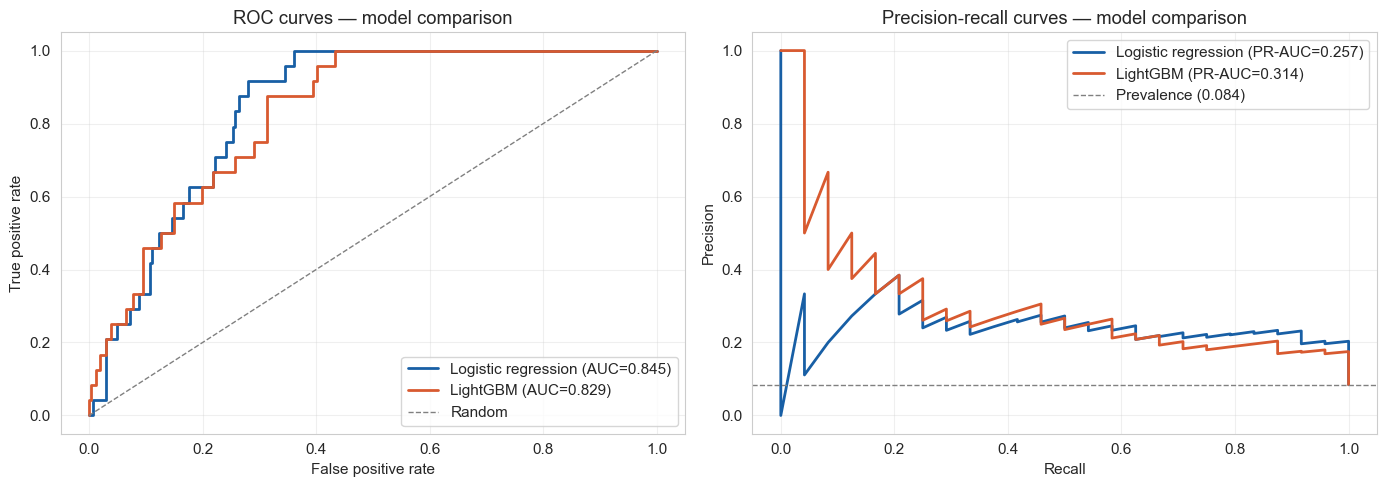

In [8]:
# Load baseline predictions for comparison
baseline_preds = pd.read_parquet("../data/predictions_baseline.parquet")
y_test_baseline = baseline_preds["y_true"].values
y_pred_baseline = baseline_preds["y_pred_proba"].values

# Side-by-side ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test_baseline, y_pred_baseline)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_proba_lgb)
axes[0].plot(fpr_lr,  tpr_lr,  color="#185FA5", lw=2, label=f"Logistic regression (AUC={0.845:.3f})")
axes[0].plot(fpr_lgb, tpr_lgb, color="#D85A30", lw=2, label=f"LightGBM (AUC={roc_auc_lgb:.3f})")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves — model comparison")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Precision-recall
prec_lr,  recall_lr,  _ = precision_recall_curve(y_test_baseline, y_pred_baseline)
prec_lgb, recall_lgb, _ = precision_recall_curve(y_test, y_pred_proba_lgb)
axes[1].plot(recall_lr,  prec_lr,  color="#185FA5", lw=2, label=f"Logistic regression (PR-AUC={0.257:.3f})")
axes[1].plot(recall_lgb, prec_lgb, color="#D85A30", lw=2, label=f"LightGBM (PR-AUC={pr_auc_lgb:.3f})")
axes[1].axhline(y=y_test.mean(), color="gray", linestyle="--", lw=1, label=f"Prevalence ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curves — model comparison")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Save the model and predictions

In [11]:
joblib.dump(final_model, "../models/lightgbm_model.pkl")

# Save predictions for later analysis
test_predictions_lgb = pd.DataFrame({
    "patientunitstayid": features.iloc[X_test.index]["patientunitstayid"].values,
    "y_true": y_test.values,
    "y_pred_proba_lgb": y_pred_proba_lgb,
})
test_predictions_lgb.to_parquet("../data/predictions_lightgbm.parquet", index=False)

print("Saved LightGBM model and predictions.")
print(f"\n=== Summary of comparison ===")
print(f"Logistic Regression: ROC-AUC = 0.845, PR-AUC = 0.257")
print(f"LightGBM:            ROC-AUC = {roc_auc_lgb:.3f}, PR-AUC = {pr_auc_lgb:.3f}")

Saved LightGBM model and predictions.

=== Summary of comparison ===
Logistic Regression: ROC-AUC = 0.845, PR-AUC = 0.257
LightGBM:            ROC-AUC = 0.829, PR-AUC = 0.314
